In [15]:
# imports and loading
from pymodulon.io import *
from pymodulon.plotting import *
from os import path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from adjustText import adjust_text

data_dir = path.join('..','data','processed_data')
interim_dir = path.join('..','data','interim')
ica_data = load_json_model(path.join(data_dir,'ZM4_ica.json.gz'))

/home/chris/miniforge3/envs/iM_miner/lib/python3.13/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/home/chris/miniforge3/envs/iM_miner/lib/python3.13/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/home/chris/miniforge3/envs/iM_miner/lib/python3.13/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/home/chris/miniforge3/envs/iM_miner/lib/python3.13/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' 

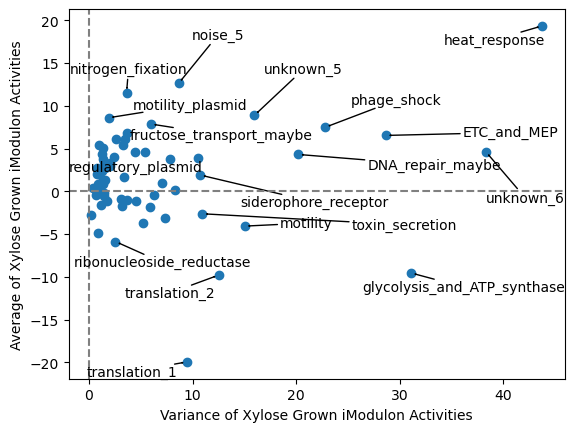

In [27]:
xylose_samples = [index for index, row in ica_data.sample_table.iterrows() if 'xylose' in str(row['Carbon Source (g/L)']).lower()]
bby_df = ica_data.A[xylose_samples]
var_df = bby_df.var(axis = 1)
mean_df = bby_df.mean(axis = 1)
to_label = set()
for sample, var in var_df.items():
    if var > 10:
        to_label.add(sample)
for sample, mean in mean_df.items():
    if mean > 7 or mean < -5:
        to_label.add(sample)

# plotting
plt.scatter(var_df, mean_df)
plt.axhline(y = 0, ls = '--', c = 'grey')
plt.axvline(x = 0, ls = '--', c = 'grey')
texts = [plt.text(var_df[i], mean_df[i], i, ha = 'center', va = 'center') for i in var_df.keys() if i in to_label]
adjust_text(texts, expand=(1.2, 2), # expand text bounding boxes by 1.2 fold in x direction and 2 fold in y direction
            arrowprops=dict(arrowstyle='->', color='k') # ensure the labeling is clear by adding arrows
            );
plt.xlabel('Variance of Xylose Grown iModulon Activities')
plt.ylabel('Average of Xylose Grown iModulon Activities')
plt.savefig('../figures/var_mean_xylose.pdf', transparent = True)
plt.show()